In [2]:
from zfish._io import import16chFlt
from zfish.swim_detect import SwimBoutUNetDetector
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from zfish.utils import *
import os

model_dir = r"D:\EnData\10161\S1\swim_detector.pt"
detector = SwimBoutUNetDetector.load(r"D:\EnData\10161\S1\swim_detector_long_context.pt")

In [29]:
bout_labels = detector.predict(
    data_path=r"D:\EnData\10161\S2\res.16chFlt",
    return_probs=True,
)
res = import16chFlt(r"D:\EnData\10161\S2\res.16chFlt")

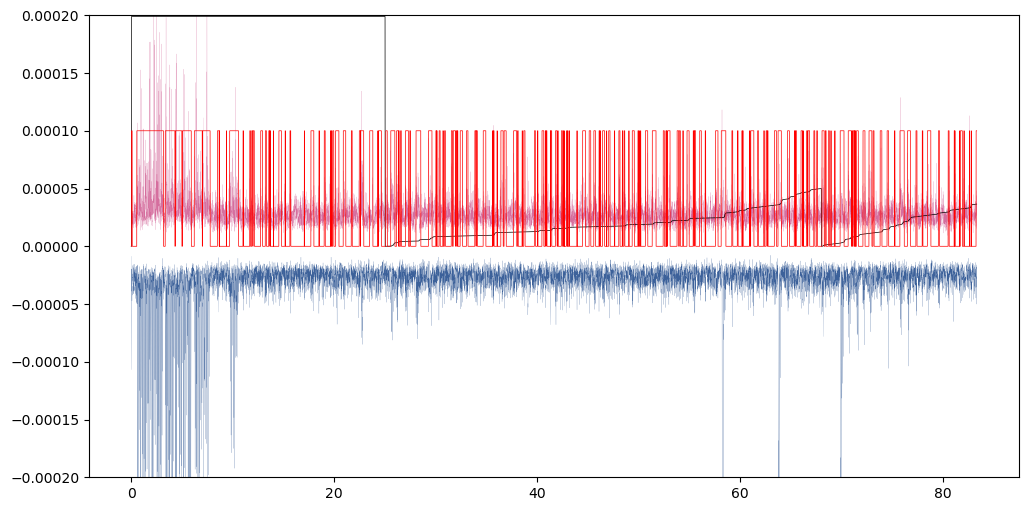

In [41]:
plt.figure(figsize=(12, 6))
x = res['behav_time']
_rg = np.arange(000000, 500000)
smoothed_prob = np.convolve(bout_labels, np.ones(200), mode='same') / np.convolve(np.ones_like(bout_labels), np.ones(200), mode='same')
is_label = smoothed_prob > 0.97
plt.plot(x[_rg], res['fltCh0'][_rg], color=ChannelColors[0], linewidth=0.1)
plt.plot(x[_rg], res['behav_pos_y'][_rg]*1e-6, color='k', linewidth=0.5)
plt.plot(x[_rg], -res['fltCh1'][_rg], color=ChannelColors[1], linewidth=0.1)
plt.plot(x[_rg], is_label[_rg]*1e-4, color='red', linewidth=0.5)
plt.ylim(-2e-4, 2e-4)
plt.show()